# ANÁLISIS ESTADÍSTICO DE LA CLASIFICACIÓN

Este notebook analiza los resultados de la clasificación generada en el notebook 5.
- Correlaciones de Spearman (flux vs variables hidrodinámicas)
- Contraste de hipótesis entre grupos (Mann-Whitney U)
- Asociación spikes–oleaje (Chi-cuadrado)

In [14]:
# ============================================================
# 0. IMPORTS
# ============================================================
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, mannwhitneyu, kruskal, chi2_contingency, rankdata

pd.set_option("display.max_columns", None)

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline


In [15]:
# ============================================================
# 1. CARGA DE DATOS
# ============================================================

base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df= pd.read_csv(os.path.join(base_path, "df_classified.csv"))

In [16]:
# ============================================================
# 2. PREPARACION DE DATOS
# ============================================================

# Columnas de clasificación disponibles
clase_cols = {
    "Wiberg": "oleaje_clase_Wiberg",
    "SIMAR": "oleaje_clase_SIMAR",
}

# Verificar cuáles existen
for nombre, col in list(clase_cols.items()):
    if col not in df.columns:
        print(f"⚠️  No se encontró columna '{col}' — se omite escenario {nombre}")
        del clase_cols[nombre]

print("Escenarios disponibles:", list(clase_cols.keys()))
print(f"Total ventanas: {len(df)}")

# Variables de oleaje
vars_oleaje = {
    "Oleaje": "Oleaje",
    "Mod_orbital": "Mod_orbital",
    "STD_orbital": "STD_orbital",
    "Oleaje_SIMAR": "Oleaje_SIMAR",
    "mean_pres": "pres__mean",
    "std_pres": "pres__standard_deviation",
}
# Solo las que existan
vars_oleaje = {k: v for k, v in vars_oleaje.items() if v in df.columns}

ALPHA = 0.05
print(f"Variables de oleaje: {list(vars_oleaje.keys())}")

Escenarios disponibles: ['Wiberg', 'SIMAR']
Total ventanas: 660
Variables de oleaje: ['Oleaje', 'Mod_orbital', 'STD_orbital', 'Oleaje_SIMAR', 'mean_pres', 'std_pres']


## 6.0 Caracterización de los clusters
Tabla con número de ventanas, oleaje medio, flujo medio y desviación típica del flujo por estado, para ambas configuraciones.

In [21]:
# ============================================================
# 6.0 CARACTERIZACIÓN DE CLUSTERS (ambas configuraciones)
# ============================================================
import numpy as np

# Configuraciones a comparar
configs = {
    "Wiberg (k=4)": {"col_clase": "oleaje_clase_Wiberg", "col_oleaje": "Oleaje"},
    "SIMAR (k=4)":  {"col_clase": "oleaje_clase_SIMAR",  "col_oleaje": "Oleaje_SIMAR"},
}

for config_name, cfg in configs.items():
    col_clase = cfg["col_clase"]
    col_oleaje = cfg["col_oleaje"]

    if col_clase not in df.columns:
        print(f"⚠️  {col_clase} no encontrada, se omite {config_name}")
        continue

    tabla = df.groupby(col_clase).agg(
        n=("flux_O2", "count"),
        oleaje_media=(col_oleaje, "mean"),
        oleaje_mediana=(col_oleaje, "median"),
        flujo_medio=("flux_O2", "mean"),
        flujo_std=("flux_O2", "std"),
        flujo_mediana=("flux_O2", "median"),
    ).round(4)

    print(f"\n{'='*60}")
    print(f"CARACTERIZACIÓN — {config_name}")
    print(f"{'='*60}")
    display(tabla)
    print()


CARACTERIZACIÓN — Wiberg (k=4)


,n,oleaje_media,oleaje_mediana,flujo_medio,flujo_std,flujo_mediana
oleaje_clase_Wiberg,,,,,,
0,137,12.0336,10.102,-7.0160,6.2528,-6.4163
1,169,13.4959,11.674,-8.0778,12.6705,-6.9795
2,190,27.0294,26.046,-9.6899,26.9258,-7.2529
3,164,30.0248,29.744,-7.5332,46.4173,-10.1382




CARACTERIZACIÓN — SIMAR (k=4)


,n,oleaje_media,oleaje_mediana,flujo_medio,flujo_std,flujo_mediana
oleaje_clase_SIMAR,,,,,,
0,121,1.8459,1.860,-6.5659,6.3663,-5.9903
1,145,2.1865,1.850,-8.1974,13.0576,-6.7747
2,212,4.2371,4.225,-9.6684,25.5895,-7.5513
3,182,4.2764,4.310,-7.5279,44.1464,-9.8755


## 6.1 Contraste de hipótesis entre grupos
Mann-Whitney U para la clasificación Wiberg. Evalúa si hay diferencia significativa en el flujo entre estados de oleaje.


CONTRASTE — Wiberg (4 clases)
  Test: Kruskal-Wallis
  H = 15.9312, p = 0.001171
  Significativo: True


,grupo_1,grupo_2,U,p,p_bonferroni,sig
0,0,1,12187.0,0.428018,1.000000,False
1,0,2,14153.0,0.177481,1.000000,False
2,0,3,14163.0,0.000098,0.000588,True
3,1,2,16791.0,0.453628,1.000000,False
4,1,3,16777.0,0.000891,0.005346,True
5,2,3,17465.0,0.049671,0.298026,False


C:\Users\noeli\AppData\Local\Temp\ipykernel_17792\415021541.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_nombre, y="flux_O2", ax=ax, palette="Set2")


  Figura guardada: boxplot_flujo_wiberg.png


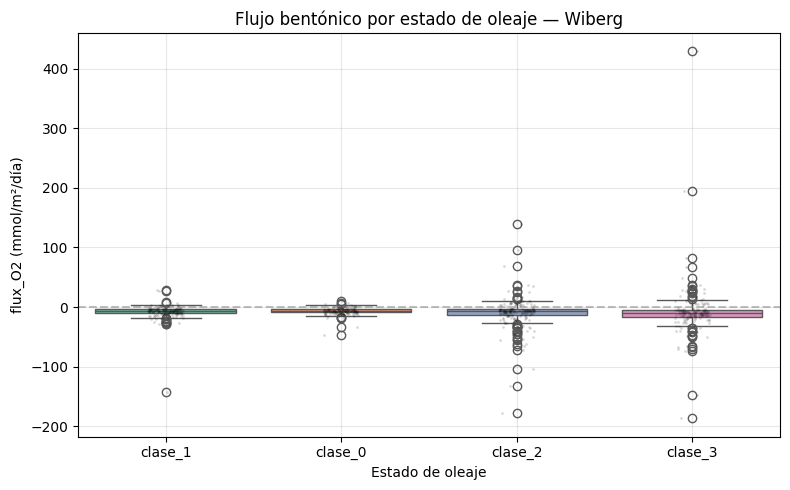


CONTRASTE — SIMAR (4 clases)
  Test: Kruskal-Wallis
  H = 20.0600, p = 0.000165
  Significativo: True


,grupo_1,grupo_2,U,p,p_bonferroni,sig
0,0,1,9646.0,0.162340,0.974040,False
1,0,2,14830.0,0.017736,0.106416,False
2,0,3,14208.0,0.000019,0.000114,True
3,1,2,16541.0,0.221604,1.000000,False
4,1,3,15997.0,0.000972,0.005832,True
5,2,3,21292.0,0.076025,0.456150,False


C:\Users\noeli\AppData\Local\Temp\ipykernel_17792\415021541.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_nombre, y="flux_O2", ax=ax, palette="Set2")


  Figura guardada: boxplot_flujo_simar.png


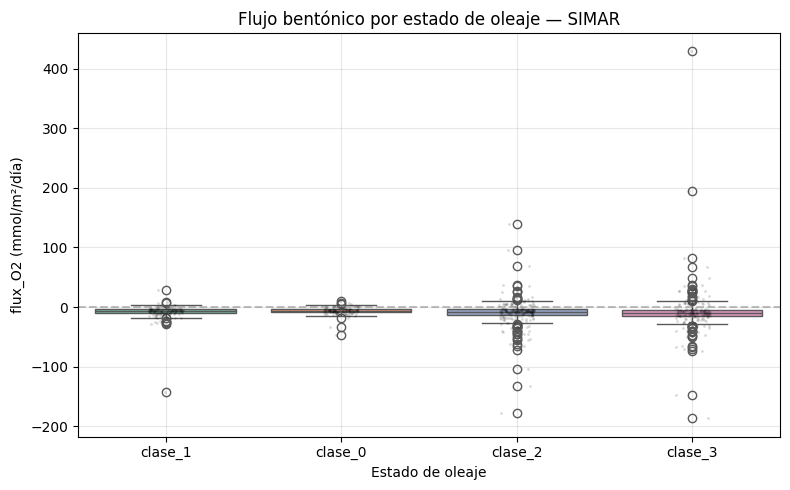

In [18]:
# ============================================================
# 6.1 MANN-WHITNEY U / KRUSKAL-WALLIS + BOXPLOTS (ambas configs)
# ============================================================
import numpy as np
from itertools import combinations

out_dir = os.path.join(BASE_PATH, "..", "Memoria", "tex", "img")
os.makedirs(out_dir, exist_ok=True)

for nombre, col_clase in clase_cols.items():
    grupos = df[[col_clase, "flux_O2"]].dropna()
    clases = sorted(grupos[col_clase].unique())
    n_clases = len(clases)
    muestras = [grupos.loc[grupos[col_clase] == c, "flux_O2"].values for c in clases]

    print(f"\n{'='*60}")
    print(f"CONTRASTE — {nombre} ({n_clases} clases)")
    print(f"{'='*60}")

    if n_clases == 2:
        stat, p = mannwhitneyu(muestras[0], muestras[1], alternative="two-sided")
        n1, n2 = len(muestras[0]), len(muestras[1])
        r_effect = 1 - (2 * stat) / (n1 * n2)
        print(f"  Test: Mann-Whitney U")
        print(f"  U = {stat:.2f}, p = {p:.6f}")
        print(f"  Tamaño del efecto (rank-biserial r) = {r_effect:.4f}")
        print(f"  Significativo: {p < ALPHA}")
    else:
        stat, p = kruskal(*muestras)
        print(f"  Test: Kruskal-Wallis")
        print(f"  H = {stat:.4f}, p = {p:.6f}")
        print(f"  Significativo: {p < ALPHA}")

        if p < ALPHA:
            pares = list(combinations(clases, 2))
            n_pares = len(pares)
            resultados_posthoc = []
            for c1, c2 in pares:
                m1 = grupos.loc[grupos[col_clase] == c1, "flux_O2"].values
                m2 = grupos.loc[grupos[col_clase] == c2, "flux_O2"].values
                stat_par, p_par = mannwhitneyu(m1, m2, alternative="two-sided")
                resultados_posthoc.append({
                    "grupo_1": c1, "grupo_2": c2,
                    "U": round(stat_par, 2), "p": round(p_par, 6),
                })
            df_ph = pd.DataFrame(resultados_posthoc)
            df_ph["p_bonferroni"] = (df_ph["p"] * n_pares).clip(upper=1.0)
            df_ph["sig"] = df_ph["p_bonferroni"] < ALPHA
            display(df_ph)

    # --- Boxplot para esta configuración ---
    col_nombre = f"{col_clase}_nombre"
    if col_nombre not in df.columns:
        col_nombre = col_clase

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x=col_nombre, y="flux_O2", ax=ax, palette="Set2")
    sns.stripplot(data=df, x=col_nombre, y="flux_O2", ax=ax,
                  color="black", alpha=0.15, size=2)
    ax.axhline(0, linestyle="--", color="gray", alpha=0.5)
    ax.set_xlabel("Estado de oleaje")
    ax.set_ylabel("flux_O2 (mmol/m²/día)")
    ax.set_title(f"Flujo bentónico por estado de oleaje — {nombre}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f"boxplot_flujo_{nombre.lower()}.png"
    fig.savefig(os.path.join(out_dir, fname), dpi=150, bbox_inches="tight")
    print(f"  Figura guardada: {fname}")
    plt.show()

## 6.2 Asociación entre flags de calidad y estado de oleaje
¿La proporción de ventanas con algún flag de calidad depende del estado de oleaje?
Se crea una variable binaria `any_flag` (1 si tiene al menos un flag activo) y se aplica Chi-cuadrado.

In [19]:
# ============================================================
# 6.2 CHI-CUADRADO: any_flag vs estado de oleaje
# ============================================================
from scipy.stats import chi2_contingency
import numpy as np

# Flags disponibles
flag_candidates = ["flag_outlier_window", "flag_outlier_global", "flag_flux_positivo", "flag_vel_baja"]
flags_disponibles = [f for f in flag_candidates if f in df.columns]
print(f"Flags disponibles: {flags_disponibles}")

# Crear variable combinada: 1 si tiene al menos un flag activo
df["any_flag"] = df[flags_disponibles].fillna(False).any(axis=1).astype(int)
print(f"Ventanas con algún flag: {df['any_flag'].sum()} / {len(df)} ({df['any_flag'].mean()*100:.1f}%)")

# Clasificación SIMAR
col_clase = clase_cols.get("SIMAR", list(clase_cols.values())[0])

# Tabla de contingencia
df_chi = df[[col_clase, "any_flag"]].dropna().copy()
tabla = pd.crosstab(
    df_chi[col_clase],
    df_chi["any_flag"],
    rownames=["estado_oleaje"],
    colnames=["any_flag"],
)

chi2_val, p_val, dof_val, expected = chi2_contingency(tabla)

# Proporción por cluster
n_total = tabla.sum(axis=1)
n_flag = tabla[1] if 1 in tabla.columns else pd.Series(0, index=tabla.index)
pct = (n_flag / n_total * 100).round(1)

detalle = pd.DataFrame({
    "n_total": n_total,
    "n_con_flag": n_flag,
    "% con flag": pct,
})

print(f"\n{'='*60}")
print(f"PROPORCIÓN DE VENTANAS CON ALGÚN FLAG POR ESTADO DE OLEAJE")
print(f"{'='*60}")
display(detalle)
print(f"\nChi-cuadrado: χ² = {chi2_val:.4f}, gl = {dof_val}, p = {p_val:.6f}")
print(f"→ {'Significativo' if p_val < ALPHA else 'No significativo'} (α = {ALPHA})")

Flags disponibles: ['flag_outlier_window', 'flag_outlier_global', 'flag_flux_positivo']
Ventanas con algún flag: 397 / 660 (60.2%)

PROPORCIÓN DE VENTANAS CON ALGÚN FLAG POR ESTADO DE OLEAJE


,n_total,n_con_flag,% con flag
estado_oleaje,,,
0,121,63,52.1
1,145,61,42.1
2,212,151,71.2
3,182,122,67.0



Chi-cuadrado: χ² = 37.5240, gl = 3, p = 0.000000
→ Significativo (α = 0.05)


## 6.3 Correlaciones de Spearman
Correlación no paramétrica entre flux_O2 y todas las variables hidrodinámicas.

In [20]:
# ============================================================
# 6.4 CORRELACIONES DE SPEARMAN: flux_O2 vs variables hidrodinámicas
# ============================================================

resultados_spear = []

for etiqueta, col_real in vars_oleaje.items():
    aux = df[["flux_O2", col_real]].dropna()
    if len(aux) < 5:
        continue
    rho, p_sp = spearmanr(aux["flux_O2"], aux[col_real])
    resultados_spear.append({
        "Variable": etiqueta,
        "Columna": col_real,
        "Spearman ρ": round(rho, 4),
        "p-value": round(p_sp, 6),
        "Significativo": p_sp < ALPHA,
        "n": len(aux),
    })

df_spearman = pd.DataFrame(resultados_spear)
print("Correlaciones Spearman: flux_O2 vs variables de oleaje")
display(df_spearman)

Correlaciones Spearman: flux_O2 vs variables de oleaje


,Variable,Columna,Spearman ρ,p-value,Significativo,n
0,Oleaje,Oleaje,-0.1665,0.000087,True,550
1,Mod_orbital,Mod_orbital,-0.1774,0.000005,True,660
2,STD_orbital,STD_orbital,-0.1723,0.000009,True,660
3,Oleaje_SIMAR,Oleaje_SIMAR,-0.1694,0.000012,True,660
4,mean_pres,pres__mean,0.0305,0.433604,False,660
5,std_pres,pres__standard_deviation,-0.1628,0.000026,True,660
